# Differential gene expression over updated cell-types

In [1]:
# Load packages
suppressPackageStartupMessages({
    library(dplyr)
    library(data.table)
    library(ggplot2)
    library(SingleCellExperiment)
    library(scater)
    library(scran)
    library(edgeR)
    library(ggrastr)
})

here::i_am("differential/01_DEG_analysis_manual.ipynb")

# Load default settings
source(here::here("settings.R"))
source(here::here("utils.R"))

set.seed(1234)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/02_Mixl1_RNA/code



In [2]:
io$basedir

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/02_Mixl1_RNA"

In [3]:
args = list()
args$sce = io$rna.sce
args$metadata = '/rds/project/rds-SDzz0CATGms/users/bt392/02_Mixl1_RNA/results/rna/mapping/sample_metadata_after_mapping.txt.gz'
args$variable = 'celltype.mapped_mnn'
args$outdir = paste0(io$basedir,"/results/rna/differential/manual")
dir.create(args$outdir, recursive=TRUE, showWarnings = FALSE)

In [4]:
# Functions
# Plotting function
gg_volcano_plot <- function(celltype_i='Allantois', top_genes=20, xlim=5, ylim=40, label_groups = NULL) {
  to.plot = de.results[variable == celltype_i]
  negative_hits <- to.plot[sig==TRUE & logFC<0,gene]
  positive_hits <- to.plot[sig==TRUE & logFC>0,gene]
  all <- nrow(to.plot[!is.na(sig)])
  to.plot = to.plot[,logFC_plot:=ifelse(logFC<=-xlim, -xlim, ifelse(logFC>=xlim, xlim, logFC))] %>%
               .[,log10_padj_fdr:=ifelse(-log10(padj_fdr)>=ylim, ylim, -log10(padj_fdr))]
  
  to.plot <- to.plot[!is.na(logFC) & !is.na(padj_fdr)] %>% .[order(-abs(logFC))]
  label_genes = c(head(to.plot[sig==T & logFC<=0, gene],n=top_genes), head(to.plot[sig==T & logFC>=0, gene],n=top_genes))
  
  p <- ggplot(to.plot, aes(x=logFC_plot, y=log10_padj_fdr)) +
    labs(x="Log fold change", y=expression(paste("-log"[10],"(q.value)"))) +
    ggrastr::geom_point_rast(aes(color=sig, size=sig)) +
    # geom_hline(yintercept = -log10(opts$threshold_fdr), color="blue") +
    geom_segment(aes(x=0, xend=0, y=0, yend=ylim*1.05), color="orange", size=0.5) +
    scale_color_manual(values=c("black","red")) +
    scale_size_manual(values=c(0.5,1)) +
    scale_x_continuous(limits=c(-xlim,xlim)) +
    scale_y_continuous(limits=c(0,ylim*1.16)) +
    annotate("text", x=0, y=ylim*1.1, size=6, label=sprintf("(%d)", all)) +
    annotate("text", x=-xlim*0.9, y=ylim*1.15, size=6, label=sprintf("%d (-)",length(negative_hits))) +
    annotate("text", x=xlim*0.9, y=ylim*1.15, size=6, label=sprintf("%d (+)",length(positive_hits))) +
    ggrepel::geom_text_repel(data=to.plot[gene %in% label_genes],
                                    aes(x=logFC_plot, y=log10_padj_fdr, label=gene), 
                                     max.overlaps=Inf, 
                                     box.padding = 0.5,
                                     bg.color='white', 
                                     bg.r = 0.1,
                                     size=5) +
    theme_classic() +
    theme(
       axis.text = element_text(color='black'),
      # axis.title = element_text(size=rel(1.0), color='black'),
      text=element_text(size=15),
      legend.position="none"
    ) + 
    ggtitle(celltype_i)
    
    
  if (length(label_groups)>0) {
    p <- p +
      annotate("text", x=-4, y=0, size=4, label=sprintf("Up in %s",label_groups[2])) +
      annotate("text", x=4, y=0, size=4, label=sprintf("Up in %s",label_groups[1]))
  }
  
  return(p)
}

In [5]:
###############
## Load data ##
###############

# Load metadata
sample_metadata <- fread(args$metadata) %>%
    .[!is.na(celltype.mapped_mnn)] %>%
   .[,pool:=stringr::str_replace_all(sample,opts$sample2pool)] %>% 
   .[,variable := .[[args$variable]]]

# Load RNA expression data as SingleCellExperiment object
sce <- load_SingleCellExperiment(args$sce, cells=sample_metadata$cell, normalise = FALSE)


### Imporove cell type annotations

In [6]:
unique(sample_metadata$celltype.mapped_mnn)

[1] "Paraxial_mesoderm"              "Erythroid3"                    
 [3] "Pharyngeal_mesoderm"            "Forebrain_Midbrain_Hindbrain"  
 [5] "NMP"                            "Surface_ectoderm"              
 [7] "Neural_crest"                   "ExE_mesoderm"                  
 [9] "Cardiomyocytes"                 "Gut"                           
[11] "Somitic_mesoderm"               "Erythroid1"                    
[13] "Spinal_cord"                    "Def._endoderm"                 
[15] "PGC"                            "Haematoendothelial_progenitors"
[17] "Intermediate_mesoderm"          "Endothelium"                   
[19] "Mesenchyme"                     "ExE_endoderm"                  
[21] "Allantois"                      "Blood_progenitors_2"           
[23] "Blood_progenitors_1"            "Erythroid2"                    
[25] "ExE_ectoderm"                   "Notochord"                     
[27] "Caudal_Mesoderm"                "Parietal_endoderm"             
[29] "Visceral_endoderm"              "Rostral_neurectoderm"          
[31] "Nascent_mesoderm"               "Anterior_Primitive_Streak"     
[33] "Caudal_epiblast"                "Mixed_mesoderm"                
[35] "Caudal_neurectoderm"

In [7]:
sample_metadata = sample_metadata[,celltype_updated := celltype.mapped_mnn] %>% 
    # Add higher resolution endothelium annotation
    .[,celltype_updated := ifelse(celltype_updated %in% c('Endothelium', 'Haematoendothelial_progenitors'), celltype_extended.mapped_mnn, celltype_updated), ] %>% 
    # Merge Erythroids 
    .[,celltype_updated := ifelse(celltype_updated %in% paste0('Erythroid', 1:3), 'Erythroid', celltype_updated)] %>%
    # Change 'ExE mesoderm' to 'Lateral plate mesoderm'
    .[,celltype_updated := ifelse(celltype_updated == 'ExE_mesoderm', 'Lateral_plate_mesoderm', celltype_updated)] %>% 
    # Improve mixed mesoderm annotation
    .[,celltype_updated := ifelse(celltype_updated == 'Mixed_mesoderm', celltype_extended.mapped_mnn, celltype_updated)] %>% 
    # Add amniotic ectoderm    
    .[,celltype_updated := ifelse(celltype_extended.mapped_mnn == 'Amniotic_ectoderm', 'Amniotic_ectoderm', celltype_updated)] %>%
    # Add YS mesothelium
    .[,celltype_updated := ifelse(celltype_extended.mapped_mnn == 'YS_mesothelium', 'YS_mesothelium', celltype_updated)] %>%
    # Change name of Def._endoderm --> Def_endoderm
    .[, celltype_updated := gsub('Def._endoderm', 'Def_endoderm', celltype_updated)] %>% 
   .[,variable := celltype_updated]


# Add sample metadata as colData
colData(sce) <- sample_metadata %>% tibble::column_to_rownames("cell") %>% DataFrame

In [8]:
unique(sample_metadata$variable)

[1] "Paraxial_mesoderm"              "Erythroid"                     
 [3] "Pharyngeal_mesoderm"            "Forebrain_Midbrain_Hindbrain"  
 [5] "NMP"                            "Surface_ectoderm"              
 [7] "Neural_crest"                   "Lateral_plate_mesoderm"        
 [9] "Cardiomyocytes"                 "Gut"                           
[11] "Somitic_mesoderm"               "Spinal_cord"                   
[13] "Def_endoderm"                   "PGC"                           
[15] "Allantois_endothelium"          "Embryo_proper_endothelium"     
[17] "Intermediate_mesoderm"          "Venous_endothelium"            
[19] "Mesenchyme"                     "ExE_endoderm"                  
[21] "Allantois"                      "Blood_progenitors_2"           
[23] "Blood_progenitors_1"            "Endocardium"                   
[25] "ExE_ectoderm"                   "YS_endothelium"                
[27] "YS_mesothelium"                 "Notochord"                     
[29] "Caudal_Mesoderm"                "Parietal_endoderm"             
[31] "Amniotic_ectoderm"              "Visceral_endoderm"             
[33] "Rostral_neurectoderm"           "EMP"                           
[35] "Haematoendothelial_progenitors" "Nascent_mesoderm"              
[37] "Anterior_Primitive_Streak"      "Caudal_epiblast"               
[39] "Caudal_neurectoderm"

In [20]:
table(sample_metadata$sample, sample_metadata$tdTom, sample_metadata$celltype_updated)

, ,  = Allantois

                       
                        FALSE TRUE
  SLX19260_Mixl1_SIGAA5   294    0
  SLX19260_Mixl1_SIGAB5     0  801
  SLX19260_Mixl1_SIGAC5   119    0
  SLX19260_Mixl1_SIGAD5     0  339
  SLX19260_Mixl1_SIGAE5   301    0
  SLX19260_Mixl1_SIGAF5     0  916

, ,  = Allantois_endothelium

                       
                        FALSE TRUE
  SLX19260_Mixl1_SIGAA5    87    0
  SLX19260_Mixl1_SIGAB5     0  190
  SLX19260_Mixl1_SIGAC5    27    0
  SLX19260_Mixl1_SIGAD5     0  151
  SLX19260_Mixl1_SIGAE5    81    0
  SLX19260_Mixl1_SIGAF5     0  322

, ,  = Amniotic_ectoderm

                       
                        FALSE TRUE
  SLX19260_Mixl1_SIGAA5    36    0
  SLX19260_Mixl1_SIGAB5     0   47
  SLX19260_Mixl1_SIGAC5    16    0
  SLX19260_Mixl1_SIGAD5     0   20
  SLX19260_Mixl1_SIGAE5    45    0
  SLX19260_Mixl1_SIGAF5     0   62

, ,  = Anterior_Primitive_Streak

                       
                        FALSE TRUE
  SLX19260_Mixl1_SIGAA5

In [21]:
# Pseudobulk by sample and variable
summed <- aggregateAcrossCells(sce, 
    id=colData(sce)[,c("variable", "sample", "tdTom")])

summed.filt <- summed[,summed$ncells >= 20]

In [22]:
# specific genes
# Genes are tested to be significantly different from the average LFC of all cell-types
de.results <- pseudoBulkSpecific(summed.filt, 
    label=summed.filt$variable,
    design=~factor(pool) + tdTom,
    coef="tdTomTRUE",
    condition=summed.filt$tdTom,
    average = 'median'
    ) %>% unlist() %>% 
        as.data.table(keep.rownames=T) %>%
        .[,`:=`(gene=str_split(rn, '\\.') %>% map_chr(2), # extract gene names
                variable=str_split(rn, '\\.') %>% map_chr(1), # extract cell type
                rn=NULL, 
                sig=ifelse(abs(logFC)>=0.5 & FDR<=0.05, TRUE, FALSE))] %>%  # significance
        .[!is.na(logFC),] %>%
        setnames('FDR', 'padj_fdr')

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


In [23]:
fwrite(de.results, file.path(args$outdir, 'pseudoBulkSpecific.txt.gz'))

In [9]:
de.results = fread(file.path(args$outdir, 'pseudoBulkSpecific.txt.gz'))

In [25]:
de.results[variable=='Def_endoderm'][order(-logFC)]

logFC,logCPM,F,PValue,padj_fdr,OtherAverage,gene,variable,sig
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<lgl>
6.851481,4.496229,12.774352,3.536238e-04,0.09773113,-0.039314856,Mcph1,Def_endoderm,FALSE
6.555654,4.392531,10.204964,1.947436e-03,0.27443227,0.098592028,Zfp383,Def_endoderm,FALSE
6.538561,4.168817,9.067261,2.610978e-03,0.31424386,-0.143286869,Cyb561d2,Def_endoderm,FALSE
6.520235,4.310742,9.555432,2.874149e-03,0.32995225,0.117946527,Morc2a,Def_endoderm,FALSE
6.376635,4.209293,8.365769,4.387179e-03,0.44845383,0.048541051,Fnip1,Def_endoderm,FALSE
6.294362,4.029497,7.386954,6.585037e-03,0.53025454,-0.050160666,Strn,Def_endoderm,FALSE
6.217889,3.940729,6.821965,9.432286e-03,0.59661876,0.019285707,Nsun5,Def_endoderm,FALSE
5.986740,3.964847,5.929244,1.491490e-02,0.70439879,-0.206836578,Fam120b,Def_endoderm,FALSE
5.835230,3.691005,4.756566,2.921784e-02,0.85579991,-0.032298774,Jmjd7,Def_endoderm,FALSE


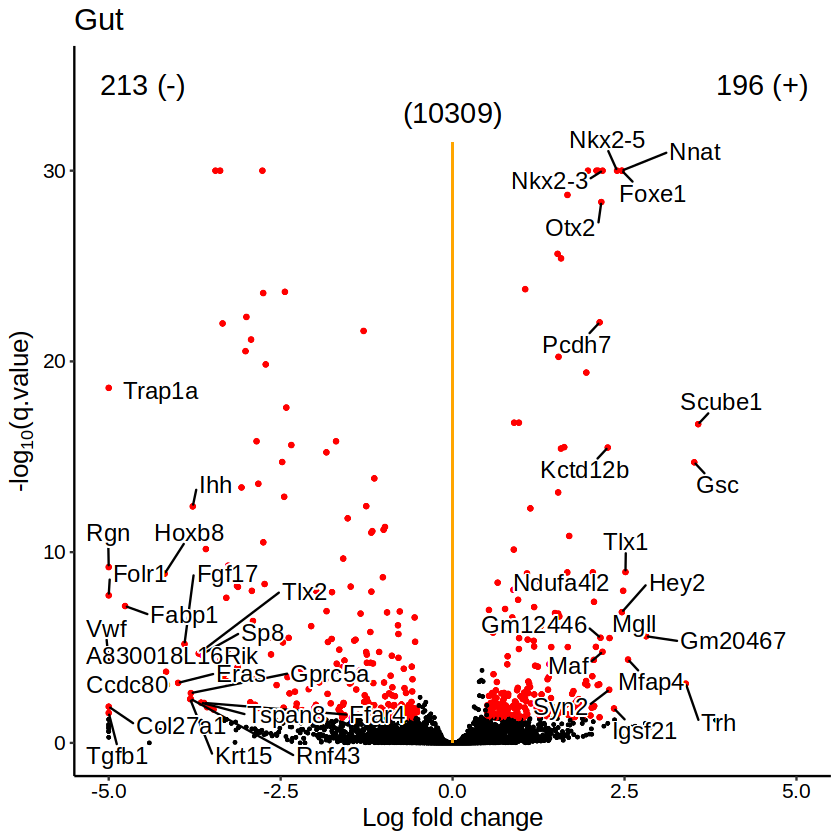

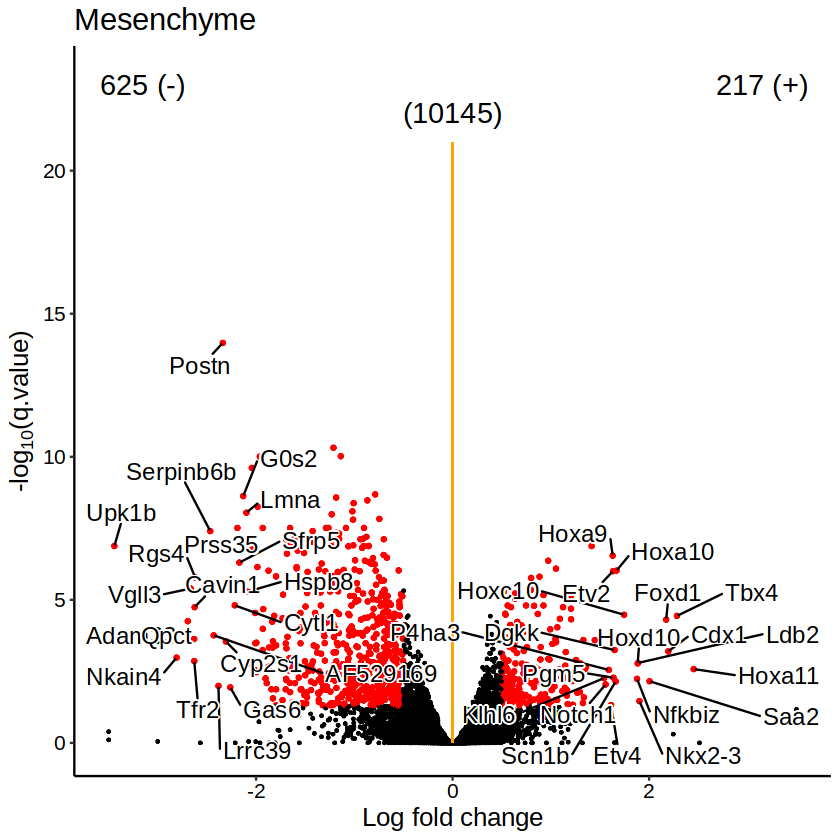

In [22]:
options(repr.plot.width=7, repr.plot.height=7)
gg_volcano_plot('Gut', ylim=30, xlim=5)
gg_volcano_plot('Mesenchyme', ylim=20, xlim=3.5)

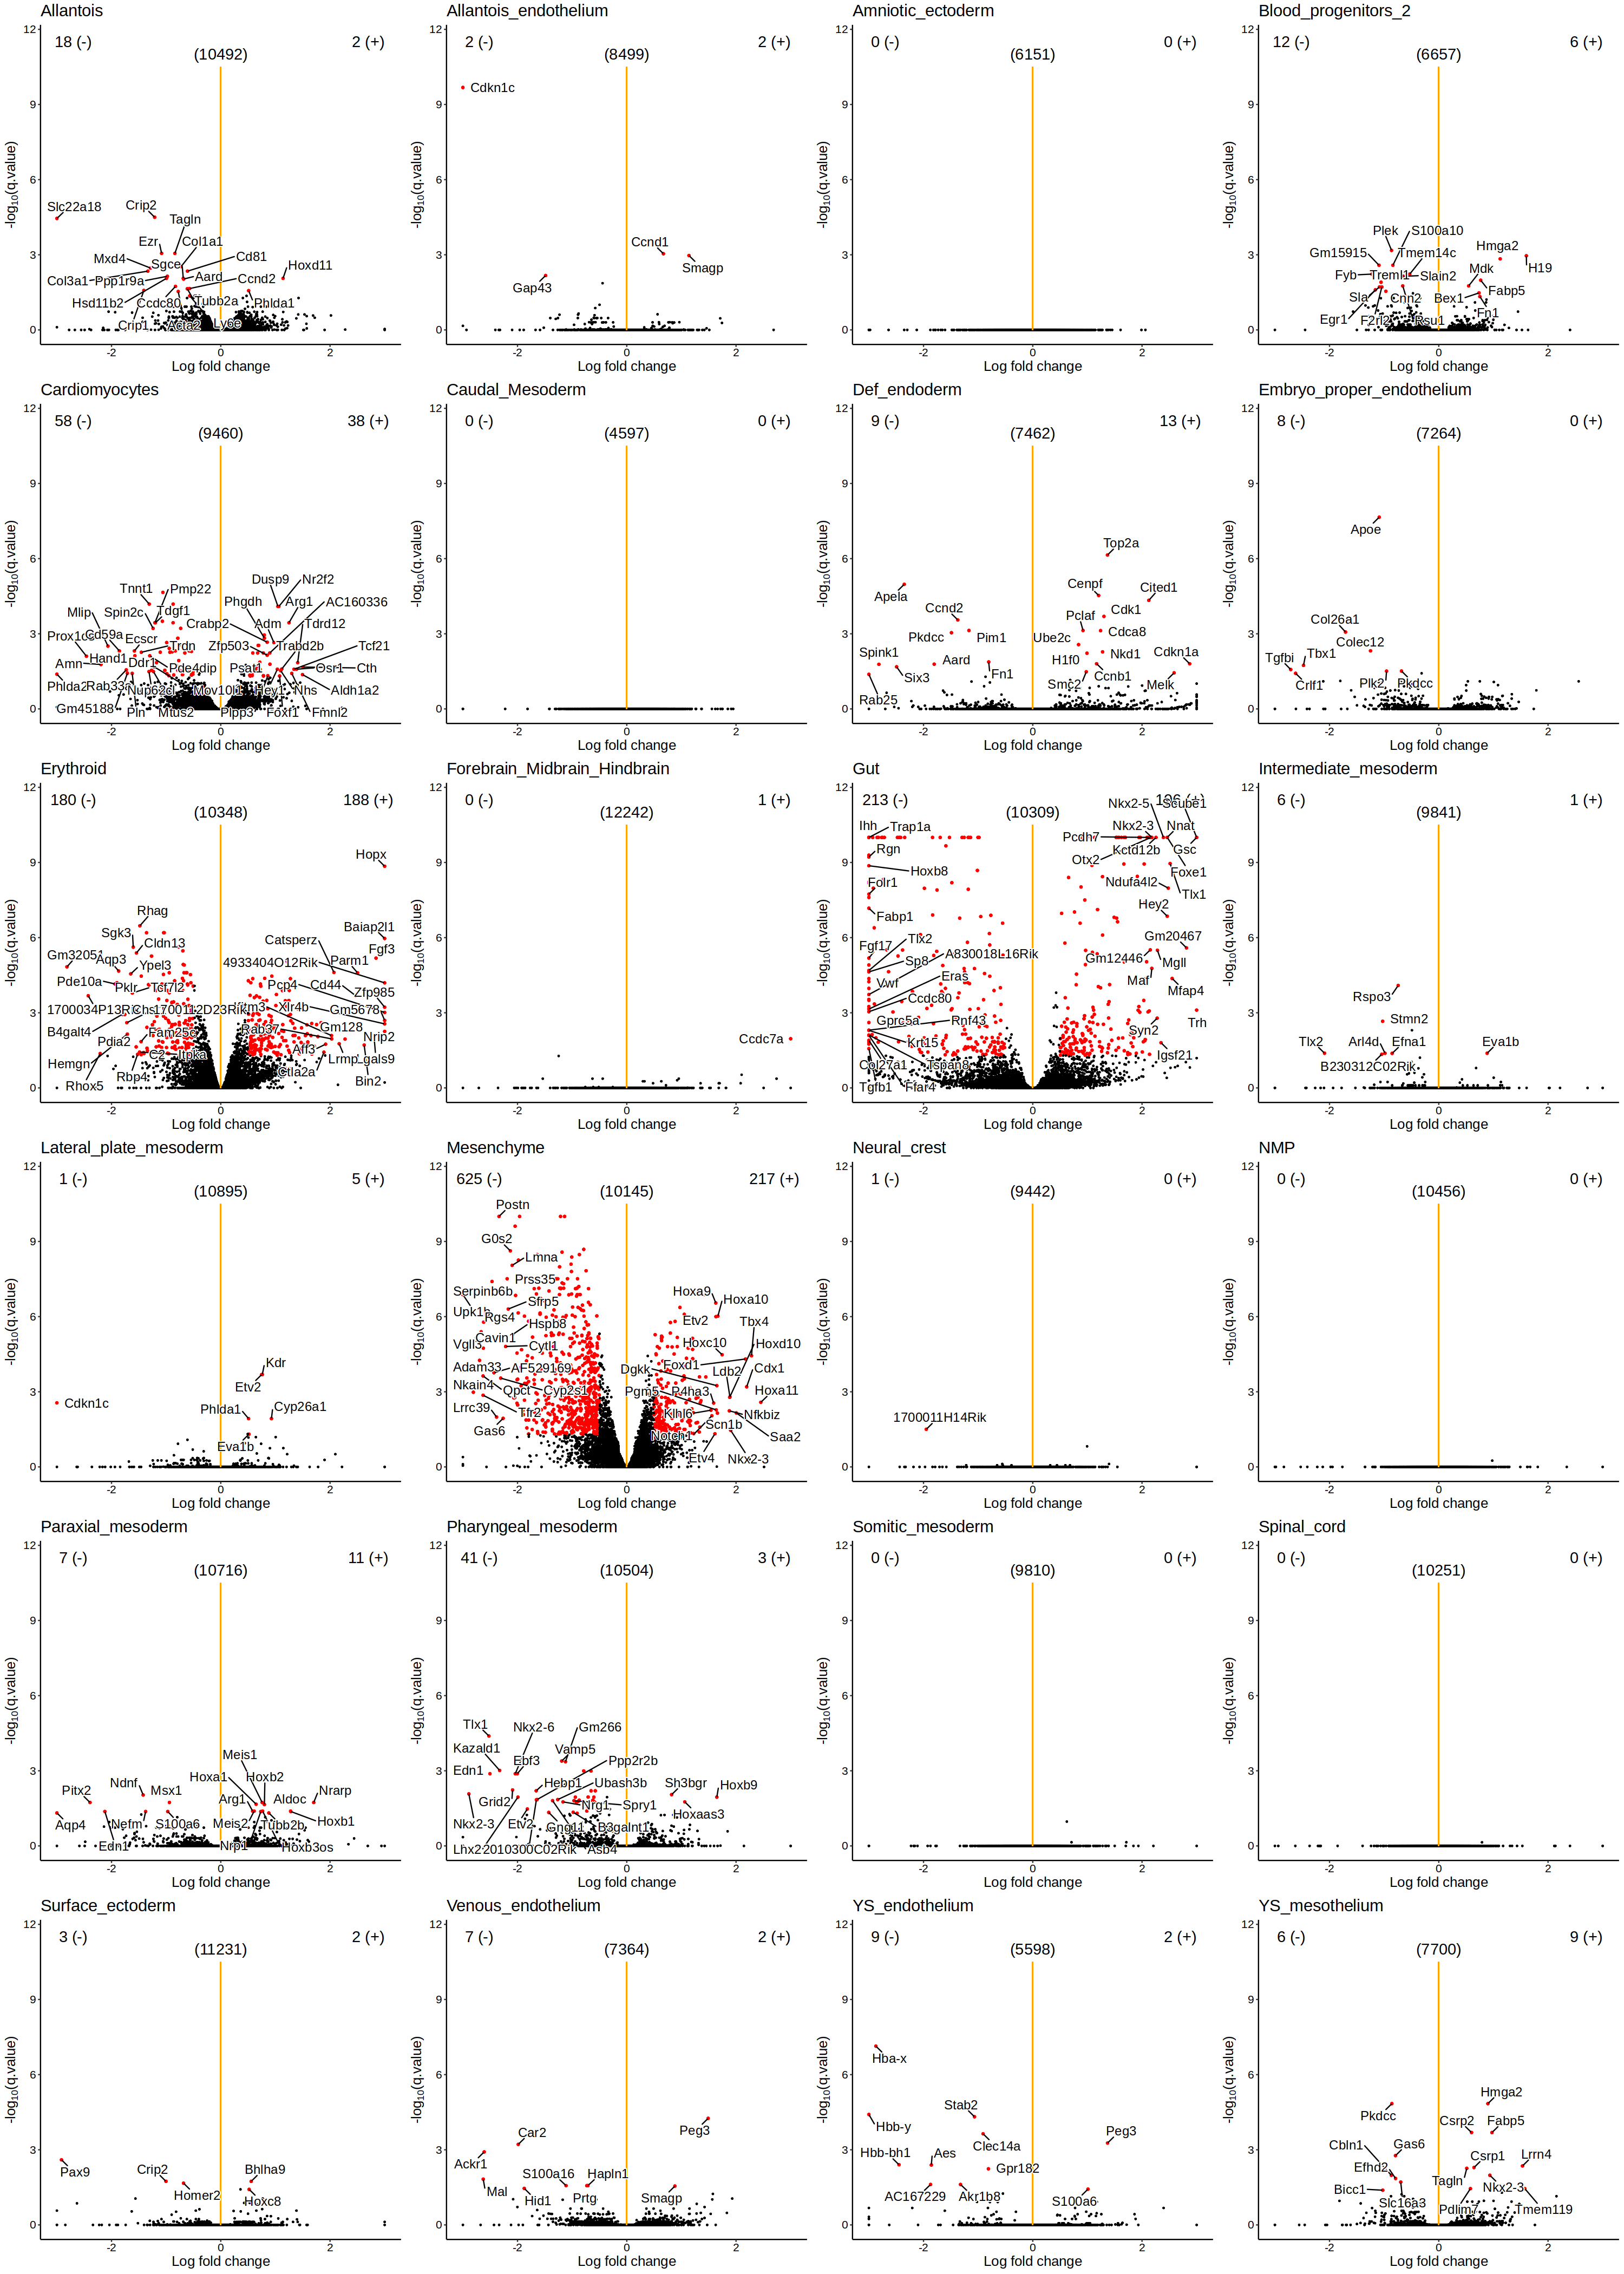

In [19]:
# Make plots
plots = lapply(unique(de.results$variable),gg_volcano_plot, ylim=10, xlim=3)
combined_plot <- cowplot::plot_grid(plotlist = plots, ncol = 4)
options(repr.plot.width=25, repr.plot.height=35)
combined_plot

### Not specific but all genes

In [ ]:
# specific genes
# Genes are tested to be significantly different from the average LFC of all cell-types
de.results <- pseudoBulkDGE(summed.filt, 
    label=summed.filt$variable,
    design=~factor(pool) + tdTom,
    lfc = 0.5,
    coef="tdTomTRUE",
    condition=summed.filt$tdTom
    ) %>% unlist() %>% 
        as.data.table(keep.rownames=T) %>%
        .[,`:=`(gene=str_split(rn, '\\.') %>% map_chr(2), # extract gene names
                variable=str_split(rn, '\\.') %>% map_chr(1), # extract cell type
                rn=NULL, 
                sig=ifelse(abs(logFC)>=0.5 & FDR<=0.05, TRUE, FALSE))] %>%  # significance
        .[!is.na(logFC),] %>%
        setnames('FDR', 'padj_fdr')

In [ ]:
fwrite(de.results, file.path(args$outdir, 'pseudoBulkAll.txt.gz'))

In [ ]:
# Make plots
plots = lapply(unique(de.results$variable),gg_volcano_plot, ylim=10, xlim=3)
combined_plot <- cowplot::plot_grid(plotlist = plots, ncol = 4)
options(repr.plot.width=25, repr.plot.height=25)
combined_plot